#### Imports

In [1]:
import os
import copy
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import time
import warnings
warnings.filterwarnings('ignore')

import kagglehub

from collections import Counter
from collections import defaultdict
from itertools import combinations

import torchvision
import torch
from torch.utils.data import Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torchvision import models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


## 1. Loading Data & EDA

### Loading Data (from Kaggle)

In [2]:
# set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# device selection

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# download latest version of dataset from kaggle
# path = kagglehub.dataset_download("michaeljkerr/20k-album-covers-within-20-genres")

# # display dataset file path
# print("Path to dataset files:", path)

In [4]:
# load dataset

# data root obtained from observing folders and files (it should be the second root printed from the previous cell)
# DATA_ROOT='/kaggle/input/20k-album-covers-within-20-genres/GAID'
DATA_ROOT = r'C:\Users\leena\.cache\kagglehub\datasets\michaeljkerr\20k-album-covers-within-20-genres\versions\1\GAID'  

# transforms for image loading
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# creating dataset
dataset = ImageFolder(root=DATA_ROOT, transform=tfm)

# display information on dataset
print("Classes/genres in the dataset:", dataset.classes)
print("Total number of images in dataset:", len(dataset))
image, label = dataset[0]
print("Image dimensions:", image.shape)

Classes/genres in the dataset: ['Blues', 'Classical', 'Country', 'DeathMetal', 'DoomMetal', 'DrumNBass', 'Electronic', 'Folk', 'Grime', 'HeavyMetal', 'HipHop', 'Jazz', 'LoFi', 'Pop', 'PsychedelicRock', 'Punk', 'Reggae', 'Rock', 'Soul', 'Techno']
Total number of images in dataset: 20000
Image dimensions: torch.Size([3, 224, 224])


### Visualizing A Few Album Covers

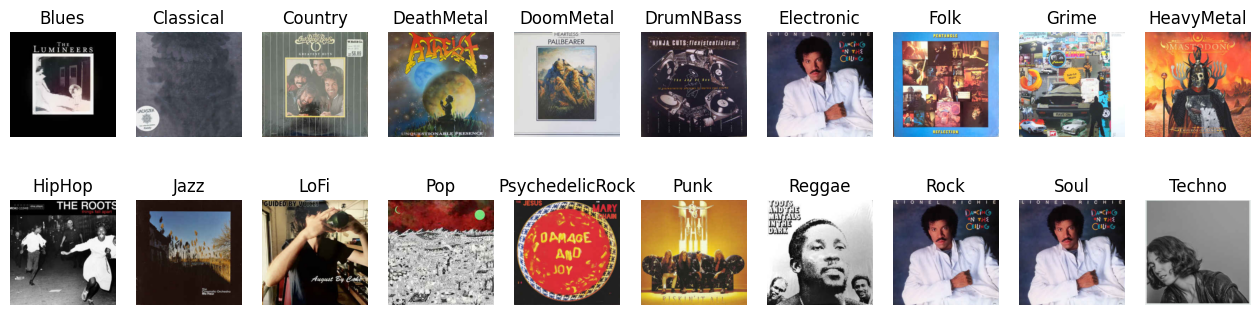

In [5]:
# show one album cover per genre/class
# first image of each genre
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(16,4))

def imshow(img, ax, title=None):
  img = img.squeeze(0)
  ax.imshow(img.permute(1, 2, 0))
  if title:
    ax.set_title(title)
  ax.axis('off')

for ax,i in zip(axes.flat,range(0,len(dataset),1000)):
  img, label = dataset[i]
  imshow(img,ax,dataset.classes[label])

### Class Distribution 
Checking for class imbalances, duplicates, etc. 

In [6]:
# count in each genre
label_counts = Counter([label for _, label in dataset.samples])

genre_distribution = {
    dataset.classes[class_idx]: count
    for class_idx, count in label_counts.items()
}
df_distribution = pd.DataFrame(
    list(genre_distribution.items()),
    columns=["Genre", "Count"]
).sort_values(by="Count", ascending=False)

print(df_distribution)

              Genre  Count
0             Blues   1000
1         Classical   1000
2           Country   1000
3        DeathMetal   1000
4         DoomMetal   1000
5         DrumNBass   1000
6        Electronic   1000
7              Folk   1000
8             Grime   1000
9        HeavyMetal   1000
10           HipHop   1000
11             Jazz   1000
12             LoFi   1000
13              Pop   1000
14  PsychedelicRock   1000
15             Punk   1000
16           Reggae   1000
17             Rock   1000
18             Soul   1000
19           Techno   1000


### Checking for Album Covers Categorized in Multiple Genres 

In [7]:
# map files to list of genres it appears in
file_to_genres = defaultdict(list)

for path, class_idx in dataset.samples:
    filename = os.path.basename(path)
    genre = dataset.classes[class_idx]
    file_to_genres[filename].append(genre)

# find files appearing in multiple genres
multi_genre = {
    fname: genres
    for fname, genres in file_to_genres.items()
    if len(genres) > 1
}

print("Number of album covers appearing in multiple genres:",
      len(multi_genre))

genre_counter = Counter()
pair_counter = Counter()

for genres in multi_genre.values():
    unique_genres = list(set(genres))

    #count individual genres
    for g in unique_genres:
        genre_counter[g] += 1

    #count genre pairs
    for pair in combinations(sorted(unique_genres),2):
        pair_counter[pair] += 1

# create df
df_genre = pd.DataFrame(
    genre_counter.items(),
    columns=["Genre","Duplicate_Count"]
).sort_values(by="Duplicate_Count",ascending=False)

df_pairs = pd.DataFrame(
    pair_counter.items(),
    columns=["Genre_Pair","Count"]
).sort_values(by="Count",ascending=False)

print("Genres most involved in duplicates:")
display(df_genre)

print("\nTop genre pairs:")
display(df_pairs.head(10))

Number of album covers appearing in multiple genres: 672
Genres most involved in duplicates:


,Genre,Duplicate_Count
7,Pop,269
13,Electronic,222
6,Rock,167
3,Soul,105
4,Jazz,90
0,Blues,85
1,Folk,85
9,HipHop,80
2,Country,61
5,PsychedelicRock,61



Top genre pairs:


,Genre_Pair,Count
43,"(Electronic, Pop)",152
15,"(Pop, Rock)",67
9,"(Country, Folk)",48
44,"(Electronic, HipHop)",44
45,"(HipHop, Pop)",39
49,"(Jazz, Soul)",37
16,"(Pop, Soul)",34
39,"(Electronic, Rock)",34
10,"(PsychedelicRock, Rock)",26
27,"(DeathMetal, DoomMetal)",24


Although our dataset is perfectly balanced, several albums are classified as multiple genres (i.e., they are "duplicated" in different genres).

## 2. Data Cleaning (Downsampling)
#### Dropping "Duplicate" Albums and Selecting Genres

- Some albums exist in multiple album folders, risking data leakage (e.g., Album in 'Pop' in training, while that same Album also is in 'Rock' in the validation/test dataset)
- To keep the task relatively simple, we drop any album images that are classified with at least 2 genres, 

In [8]:
# # Create DF with file paths and genre indices 
# df = pd.DataFrame(dataset.imgs,columns=['path', 'genre_idx'])
# df['filename'] = df['path'].apply(lambda x: os.path.basename(x))

# # IDENTIFY AND REMOVE DUPLICATES -------------------------------------
# file_counts = df.groupby('filename')['genre_idx'].transform('count')

# df_clean = df[file_counts == 1].copy()

# albums_dropped_num = df['filename'].nunique() - df_clean.shape[0]

# print('DROPPING DUPLICATES:\n')
# print(f'Number of albums dropped: {albums_dropped_num}')
# print(f'Samples after removing multi-genre duplicates: {df_clean.shape[0]}')
# print('-' * 70)

# # SUBSAMPLING  
# counts = df_clean['genre_idx'].value_counts()
# min_n = counts.min()
# min_genre = dataset.classes[counts.idxmin()]

# df_balanced = df_clean.groupby('genre_idx').sample(n=min_n, random_state=42)

# balanced_indices = df_balanced.index.tolist()
# balanced_dataset = Subset(dataset, balanced_indices)

# print('SUBSAMPLING:\n')
# print(f"New minority class: '{min_genre}' with {min_n} samples.")
# print(f"Final balanced dataset size: {len(balanced_dataset)}")

In [9]:
# SELECT GENRES

# SELECTED_GENRES = [
#     #'Metal', 
#     #'Electronic', 
#     'Classical', 
#     'HipHop', 
#     'Jazz', 
#     #'Rock', 
#     'Country', 
#     'Reggae', 
#     #'Pop', 
#     #'Blues'
# ]

SELECTED_GENRES = [
    'Classical', 
    'DoomMetal', 
    'DeathMetal', 
    'Reggae', 
    'Punk', 
]


new_class_to_idx = {g: i for i, g in enumerate(SELECTED_GENRES)}

filtered_samples = []
for path, label in dataset.samples:
    genre = dataset.classes[label]
    if genre in SELECTED_GENRES:
        new_label = new_class_to_idx[genre]   # remap to 0–3
        filtered_samples.append((path, new_label))

dataset.samples = filtered_samples
dataset.imgs = filtered_samples
dataset.classes = SELECTED_GENRES
dataset.class_to_idx = new_class_to_idx

print("New dataset size:", len(dataset))
print("New class_to_idx:", dataset.class_to_idx)

New dataset size: 5000
New class_to_idx: {'Classical': 0, 'DoomMetal': 1, 'DeathMetal': 2, 'Reggae': 3, 'Punk': 4}


In [10]:
# DROP DUPLICATE ALBUMS

file_to_genres = defaultdict(list)

for path, class_idx in dataset.samples:
    filename = os.path.basename(path)
    genre = dataset.classes[class_idx]
    file_to_genres[filename].append(genre)

# Identify filenames appearing in multiple genres
multi_genre_files = {
    fname for fname, genres in file_to_genres.items()
    if len(set(genres)) > 1
}

print("Number of multi-genre album covers:", len(multi_genre_files))

# Only single-genre samples
filtered_samples = [
    (path, class_idx)
    for path, class_idx in dataset.samples
    if os.path.basename(path) not in multi_genre_files
]

print("Original dataset size:", len(dataset.samples))
print("Filtered dataset size:", len(filtered_samples))

# Replace dataset samples with filtered ones
dataset.samples = filtered_samples
dataset.imgs = filtered_samples  # required for ImageFolder compatibility

print("New dataset size:", len(dataset))

Number of multi-genre album covers: 26
Original dataset size: 5000
Filtered dataset size: 4948
New dataset size: 4948


#### Class Distribution After Downsampling

In [11]:
label_counts = Counter([label for _, label in dataset.samples])

genre_distribution = {
    dataset.classes[class_idx]: count
    for class_idx, count in label_counts.items()
}
df_distribution = pd.DataFrame(
    list(genre_distribution.items()),
    columns=["Genre", "Count"]
).sort_values(by="Count", ascending=False)

print(df_distribution)

        Genre  Count
0   Classical    999
4      Reggae    999
3        Punk    999
2   DoomMetal    976
1  DeathMetal    975


### Data Split (Train/Validation/Test) and Creating DataLoaders
- Split: 70/15/15 
- Transformations: Normalization, Resize (for computational efficiency)
- Batch Size: 32

In [12]:
standard_tfm = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset.transform = standard_tfm

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - val_size - train_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

# Create dataloaders 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# display number of train/val/test batches
print("--------------------------------------------------")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

--------------------------------------------------
Number of training batches: 109
Number of validation batches: 24
Number of test batches: 24


In [13]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}") # Should be [32, 3, 64, 64]
print(f"Max pixel value: {images.max().item():.4f}") # Should be ~2.0-2.6
print(f"Min pixel value: {images.min().item():.4f}") # Should be ~ -2.1

Image batch shape: torch.Size([32, 3, 64, 64])
Max pixel value: 2.6400
Min pixel value: -2.1179


## 3. Baseline CNN Model
- `BaselineCNN_GAP`: BaselineCNN with a 1x1 conv nd global average pooling (to reduce parameters and computational time)
- `BaselineCNN`: BaselineCNN with a flattened later

### Class Implementation

In [14]:
class BaselineCNN_GAP(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN_GAP, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            # input: 3 x 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 channels (RGB) -> 32 channels; kernel 3x3
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224/2 = 112 || 128/2 = 64
            nn.Dropout(p=0.25),
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112/2 = 56 || 64/2 = 32
            nn.Dropout(p=0.25),
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),
        )

        # 1x1 Conv 
        self.conv_1x1 = nn.Conv2d(64, num_classes, kernel_size=1)
        # GAP 
        self.gap = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.conv_1x1(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        return x

In [15]:
baseline_model_gap = BaselineCNN_GAP(num_classes=5).to(device)
summary(baseline_model_gap, (3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 32, 32]          --
|    └─Conv2d: 2-1                       [-1, 32, 64, 64]          896
|    └─ReLU: 2-2                         [-1, 32, 64, 64]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 32, 32]          --
|    └─Dropout: 2-4                      [-1, 32, 32, 32]          --
├─Sequential: 1-2                        [-1, 64, 16, 16]          --
|    └─Conv2d: 2-5                       [-1, 64, 32, 32]          18,496
|    └─ReLU: 2-6                         [-1, 64, 32, 32]          --
|    └─MaxPool2d: 2-7                    [-1, 64, 16, 16]          --
|    └─Dropout: 2-8                      [-1, 64, 16, 16]          --
├─Sequential: 1-3                        [-1, 64, 16, 16]          --
|    └─Conv2d: 2-9                       [-1, 64, 16, 16]          36,928
|    └─ReLU: 2-10                        [-1, 64, 16, 16]          --
|    └

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 32, 32]          --
|    └─Conv2d: 2-1                       [-1, 32, 64, 64]          896
|    └─ReLU: 2-2                         [-1, 32, 64, 64]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 32, 32]          --
|    └─Dropout: 2-4                      [-1, 32, 32, 32]          --
├─Sequential: 1-2                        [-1, 64, 16, 16]          --
|    └─Conv2d: 2-5                       [-1, 64, 32, 32]          18,496
|    └─ReLU: 2-6                         [-1, 64, 32, 32]          --
|    └─MaxPool2d: 2-7                    [-1, 64, 16, 16]          --
|    └─Dropout: 2-8                      [-1, 64, 16, 16]          --
├─Sequential: 1-3                        [-1, 64, 16, 16]          --
|    └─Conv2d: 2-9                       [-1, 64, 16, 16]          36,928
|    └─ReLU: 2-10                        [-1, 64, 16, 16]          --
|    └

In [16]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            # input: 3 x 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 channels (RGB) -> 32 channels; kernel 3x3
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224/2 = 112
            nn.Dropout(p=0.25),
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112/2 = 56
            nn.Dropout(p=0.25),
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),
        )

        # Flatten Layer
        self.flatten = nn.Flatten() # (64 * 56 * 56 = 200,704)

        # Fully Connected Layer / (small) Dense Head
        self.fully_connected = nn.Sequential(
            nn.Linear(64 * 56 * 56, 64), # 200,704 -> 64 hidden nodes
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
        )

        # Ouput Layer
        self.output_layer = nn.Linear(64, num_classes) # 64 -> 10 unit output layer

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fully_connected(x)
        x = self.output_layer(x)

        return x
    
# Create model and inspect
baseline_model = BaselineCNN().to(device)

# Print model architecture
print(f"\nTotal parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in baseline_model.parameters() if p.requires_grad):,}")


Total parameters: 12,902,090
Trainable parameters: 12,902,090


In [17]:
# summary(baseline_model, (3,224,224))

### Training Helper Functions

In [18]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch
    Returns avg loss, accuracy, and time 
    """
    model.train()
    running_loss = 0.0          # Collective loss of each image
    correct = 0                 # Number of images predicted correct 
    total = 0                   # Number of images trained on 

    epoch_start = time.time()
    for images, labels in train_loader:
        # Move data to same device
        images, labels = images.to(device), labels.to(device)

        # Zero out gradients 
        optimizer.zero_grad()

        # Forward pass (compute predicted outputs and loss)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass 
        loss.backward()

        # Update params 
        optimizer.step()

        # Compute stats 
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()  
    
    epoch_time = time.time() - epoch_start
    epoch_loss = running_loss / total       # Avg loss per image 
    epoch_acc = 100. * (correct / total)
    
    return epoch_loss, epoch_acc, epoch_time

In [19]:
def evaluate(model, data_loader, criterion, device, test=False):
    """Evaluate model and returns avg loss and accuracy. Primarily used for Test and Validation sets
       If test=True, return all predictions and all labels (for plotting/confusion matrices)
       Note that test MUST be False when running train_model()
    """
    model.eval()
    running_loss = 0
    correct = 0
    total = 0 

    # For test=True 
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass 
            outputs = model(images)
            loss = criterion(outputs,labels)

            # Compute stats 
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Store prediction and label 
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    if test:
        return epoch_loss, epoch_acc, all_preds, all_labels
    else:
        return epoch_loss, epoch_acc

In [20]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    """Trains a model and returns history of stats and average epoch time"""

    # --------- INIITALIZE/SET UP ------------------
    history = {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': []}
    epoch_times = []        # later will take the mean

    print("Starting training...")
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Time':<12}")
    print("-" * 70)

    # -------- START TRAINING -----------------------
    for epoch in range(num_epochs):
        train_loss, train_acc, epoch_time = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # store metrics 
        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)
        epoch_times.append(epoch_time)

        print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.2f} {val_acc:<12.2f} {epoch_time:<12.2f}")
        # print every 5 epochs 
        # if (epoch+1) % 5 == 0 or epoch == 0:
        #     print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f} {epoch_time:<12.4f}s")
    
    print("Training Complete\n")
    avg_epoch_time = np.mean(epoch_times)
    print(f"Average Run Time per Epoch: {avg_epoch_time:.2f}")

    return history, avg_epoch_time        

In [21]:
def plot_accuracy(train_losses, train_accs, val_losses, val_accs):
  # Plot training curves
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Loss plot
  axes[0].plot(train_losses, label='Train Loss', marker='o')
  axes[0].plot(val_losses, label='Val Loss', marker='o')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].set_title('Training and Val Loss')
  axes[0].legend()
  axes[0].grid(True)

  # Accuracy plot
  axes[1].plot(train_accs, label='Train Accuracy', marker='o')
  axes[1].plot(val_accs, label='Val Accuracy', marker='o')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy (%)')
  axes[1].set_title('Training and Val Accuracy')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

In [22]:
def generate_confusion_matrix(y_true, y_pred, class_names, model_name=''):
    """Return and print confusion matrix for test set"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix {model_name}")
    plt.show()

    return cm

### Training BaselineCNN 

#### Hyperparameters

In [23]:
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
# Note BS = 32

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(baseline_model_gap.parameters(), lr=LEARNING_RATE)

#### Training the BaselineCNN Model

In [24]:
baseline_gap_history, baseline_gap_avg_time = train_model(
    model = baseline_model_gap,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    optimizer = optimizer,
    num_epochs = NUM_EPOCHS,
    device = device
)

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Time        
----------------------------------------------------------------------
1        1.5517       26.65        1.53         29.65        28.67       
2        1.5220       29.69        1.53         31.67        48.34       
3        1.5102       31.68        1.51         32.21        48.32       
4        1.4855       34.59        1.48         32.21        60.62       
5        1.4642       36.62        1.46         33.29        44.02       
6        1.4435       37.74        1.46         34.10        50.40       
7        1.4262       37.86        1.44         38.68        48.69       
8        1.4075       38.61        1.42         36.39        42.57       
9        1.3945       39.88        1.43         36.93        43.13       
10       1.3862       40.49        1.41         38.14        41.81       
11       1.3811       40.66        1.41         40.57        44.95       
12       1.3623     

#### Plotting Loss and Accuracy Curves From Training and Validation Sets

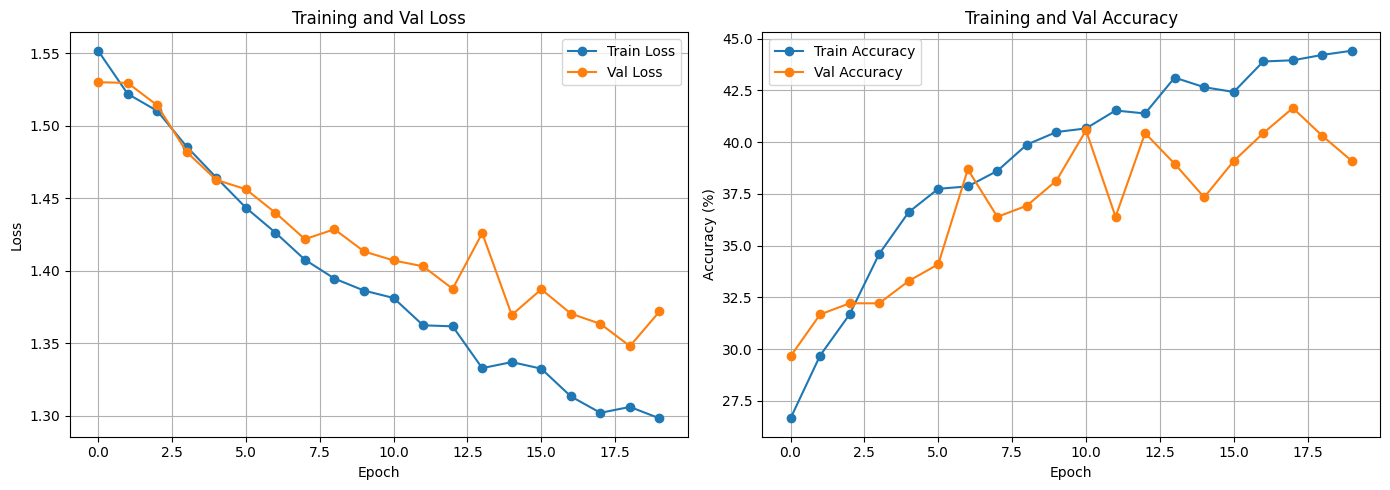

In [25]:
plot_accuracy(baseline_gap_history['train_losses'], baseline_gap_history['train_accs'], 
              baseline_gap_history['val_losses'], baseline_gap_history['val_accs'])

#### Evaluate on Test Data

In [26]:
test_loss, test_acc, y_pred, y_true = evaluate(
    model = baseline_model_gap,
    data_loader= test_loader,
    criterion = criterion,
    device = device,
    test = True
)

print('BaselineCNN (with GAP and 1x1 Conv) ')
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

BaselineCNN (with GAP and 1x1 Conv) 
Test Loss: 1.3551
Test Accuracy: 39.4347


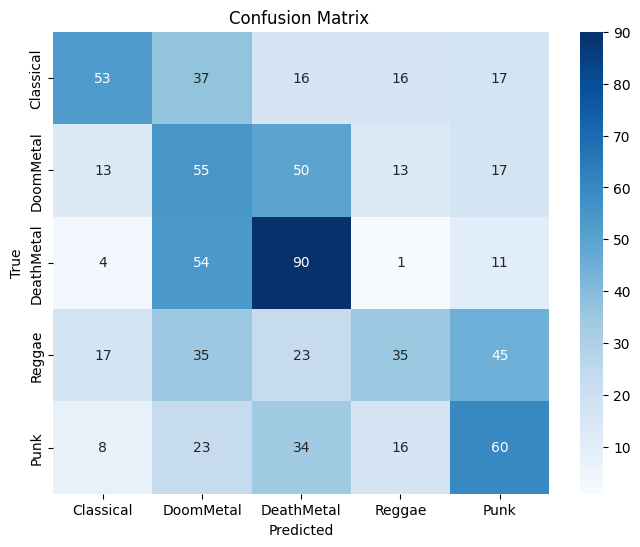

In [27]:
cm = generate_confusion_matrix(y_true, y_pred, SELECTED_GENRES)

## 4. ResNet-50 Model: Initial Run

### Initial ResNet-50 Model

In [28]:
# get weights and pretrained ResNet-50 model
weights = models.ResNet50_Weights.DEFAULT
resnet_model = models.resnet50(weights=weights)

# replace final fc layer: (in_features -> number of genres)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, len(SELECTED_GENRES))

# freeze early layers
for param in resnet_model.parameters():
    param.requires_grad = False

# unfreeze last block + fc layer
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# unfreeze classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# move model to device
resnet_model = resnet_model.to(device)

# model specs
print(resnet_model)
print(f"\nTotal parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [29]:
target_layers = [resnet_model.layer4[-1]]
cam = GradCAM(model=resnet_model, target_layers=target_layers)
print(resnet_model) # model remains unchanged (gradcam does not modify model architecture: it registers forward and backward hooks which are just attached to the layer)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Training ResNet-50

In [30]:
RESNET_NUM_EPOCHS = 20

# Loss function: Cross-Entropy Loss
criterion = nn.CrossEntropyLoss()

# Adam Optimizer (learning rate = 0.001)
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [31]:
# Training loop for ResNet-50

resnet_train_losses = []
resnet_train_accs = []
resnet_val_losses = []
resnet_val_accs = []
resnet_epoch_times = []
best_val_loss = float('inf')
patience = 5
counter = 0
best_model=None

print("Starting training for ResNet-50.")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Time':<12}")
print("-" * 70)

for epoch in range(RESNET_NUM_EPOCHS):
  # Train one epoch
  resnet_train_loss,resnet_train_acc, epoch_time = train_one_epoch(resnet_model,train_loader,criterion,optimizer,device)

  # Evaluate with validation set
  resnet_val_loss,resnet_val_acc = evaluate(resnet_model,val_loader,criterion,device)

  # Update scheduler
  scheduler.step(resnet_val_loss)

  # Update metrics
  resnet_train_losses.append(resnet_train_loss)
  resnet_train_accs.append(resnet_train_acc)
  resnet_val_losses.append(resnet_val_loss)
  resnet_val_accs.append(resnet_val_acc)
  resnet_epoch_times.append(epoch_time)

  print(f"{epoch+1:<8} {resnet_train_loss:<12.4f} {resnet_train_acc:<12.2f} {resnet_val_loss:<12.4f} {resnet_val_acc:<12.2f} {epoch_time:<12.2f}")

  # Early stopping
  if resnet_val_loss < best_val_loss:
    best_val_loss = resnet_val_loss
    best_model = copy.deepcopy(resnet_model.state_dict())
    counter = 0
  else:
    counter += 1
    if counter >= patience:
      print(f"Early stopping triggered at {counter+1} epochs.")
      break

# restore best model
if best_model is not None:
  resnet_model.load_state_dict(best_model)

avg_epoch_time = np.mean(resnet_epoch_times)

print(f"Best validation loss: {best_val_loss:.4f}")
print(f'Average Time Per Epoch: {avg_epoch_time:.2f}')

Starting training for ResNet-50.
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Time        
----------------------------------------------------------------------
1        1.3166       45.97        1.1593       51.35        72.69       
2        0.7097       75.43        1.3578       54.99        76.79       
3        0.2705       91.11        1.5061       50.54        69.82       
4        0.1540       95.81        1.8163       48.52        73.83       
5        0.0605       98.67        1.7762       51.48        69.61       
6        0.0294       99.34        1.8779       52.02        70.11       
Early stopping triggered at 6 epochs.
Best validation loss: 1.1593
Average Time Per Epoch: 72.14


### Visualizing Loss and Accuracy for ResNet-50

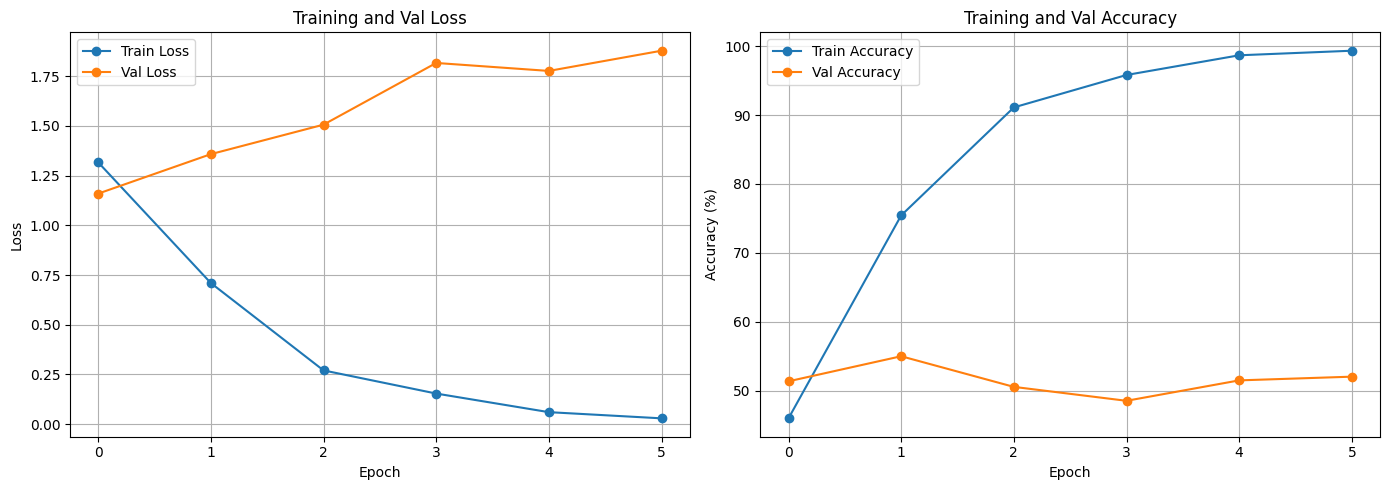

In [32]:
plot_accuracy(resnet_train_losses, resnet_train_accs, resnet_val_losses, resnet_val_accs)

We observe that our model is extremely overfiting after the first epoch. This could be due to our lack of data for a powerful model with significantly more parameters. 

### Evaluating Test Set

In [33]:
resnet_test_loss,resnet_test_acc,resnet_actual,resnet_pred = evaluate(resnet_model, test_loader, criterion, device, test=True)

print(f"ResNet-50 Test Dataset Loss: {resnet_test_loss:.2f}")
print('\n')
print(f"ResNet-50 Test Dataset Accuracy {resnet_test_acc:.2f}")

ResNet-50 Test Dataset Loss: 1.14


ResNet-50 Test Dataset Accuracy 53.43


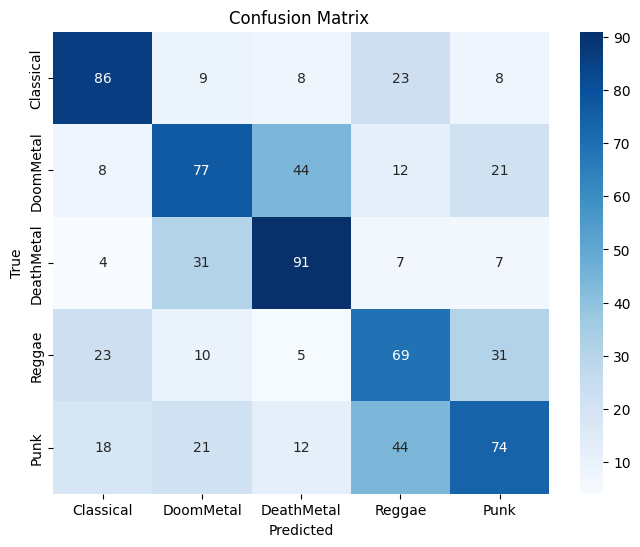

In [34]:
resnet_cm = generate_confusion_matrix(resnet_actual, resnet_pred, SELECTED_GENRES)

## 5. ResNet-50 Model Refinements

In an attempt to mitigate overfitting, we make will make a few refinements (adding regularization via a dropout layer, and selective freezing, lowered LR)

#### Implementing ResNet-50 Model 2

In [35]:
# 1. Load weights and model
weights = models.ResNet50_Weights.DEFAULT
resnet_model_2 = models.resnet50(weights=weights)

# 2. FREEZE EVERYTHING FIRST
# Ensures we don't accidentally let the model drift before we're ready
for param in resnet_model_2.parameters():
    param.requires_grad = False

# 3. REPLACE FC LAYER WITH REGULARIZATION
in_features = resnet_model_2.fc.in_features
resnet_model_2.fc = nn.Sequential(
    nn.Dropout(p=0.5),      # Shut down 50% of neurons randomly during training
    nn.Linear(in_features, len(SELECTED_GENRES))
)

# 4. SELECTIVE UNFREEZING
for param in resnet_model_2.layer4.parameters():
    param.requires_grad = True

# 5. MOVE TO DEVICE
resnet_model_2 = resnet_model_2.to(device)

# Verify the trainable parameters
trainable_params = sum(p.numel() for p in resnet_model_2.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 14,974,981


#### Training ResNet-50 Model 2

In [36]:
# ------ HYPERPARAMETERS ------
RESNET_NUM_EPOCHS = 15

# Loss function: Cross-Entropy Loss
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = optim.Adam([
    {'params': resnet_model_2.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet_model_2.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

# ------ TRAINING LOOP ------

resnet2_train_losses = []
resnet2_train_accs = []
resnet2_val_losses = []
resnet2_val_accs = []
resnet2_epoch_times = []
best_val_loss = float('inf')
patience = 5
counter = 0
best_model=None

print("Starting training for ResNet-50.")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Time':<12}")
print("-" * 70)

for epoch in range(RESNET_NUM_EPOCHS):
  # Train one epoch
  resnet2_train_loss,resnet2_train_acc, epoch_time = train_one_epoch(resnet_model_2,train_loader,criterion,optimizer,device)

  # Evaluate with validation set
  resnet2_val_loss,resnet2_val_acc = evaluate(resnet_model_2,val_loader,criterion,device)

  # Update scheduler
  scheduler.step(resnet2_val_loss)

  # Update metrics
  resnet2_train_losses.append(resnet2_train_loss)
  resnet2_train_accs.append(resnet2_train_acc)
  resnet2_val_losses.append(resnet2_val_loss)
  resnet2_val_accs.append(resnet2_val_acc)
  resnet2_epoch_times.append(epoch_time)

  print(f"{epoch+1:<8} {resnet2_train_loss:<12.4f} {resnet2_train_acc:<12.2f} {resnet2_val_loss:<12.4f} {resnet2_val_acc:<12.2f} {epoch_time:<12.2f}")

  # Early stopping
  if resnet2_val_loss < best_val_loss:
    best_val_loss = resnet2_val_loss
    best_model = copy.deepcopy(resnet_model_2.state_dict())
    counter = 0
  else:
    counter += 1
    if counter >= patience:
      print(f"Early stopping triggered at {counter+1} epochs.")
      break

# restore best model
if best_model is not None:
  resnet_model_2.load_state_dict(best_model)

avg_epoch_time = np.mean(resnet2_epoch_times)

print(f"Best validation loss: {best_val_loss:.4f}")
print(f'Average Time Per Epoch: {avg_epoch_time:.2f}')

Starting training for ResNet-50.
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Time        
----------------------------------------------------------------------
1        1.5264       32.52        1.3782       42.18        73.49       
2        1.3508       45.11        1.3512       46.09        73.81       
3        1.2746       48.46        1.3333       43.67        72.38       
4        1.2330       50.25        1.3315       44.07        75.10       
5        1.1572       52.90        1.3454       43.53        72.26       
6        1.1323       53.94        1.3320       44.20        72.45       
7        1.1037       55.88        1.3402       44.74        72.65       
8        1.0445       58.33        1.3876       45.82        72.32       
9        1.0092       60.53        1.3298       44.20        71.75       
10       1.0021       60.73        1.3270       43.67        75.25       
11       0.9980       60.70        1.3270       45.69        75.28       
12      

#### Visualizing ResNet-50 Model 2

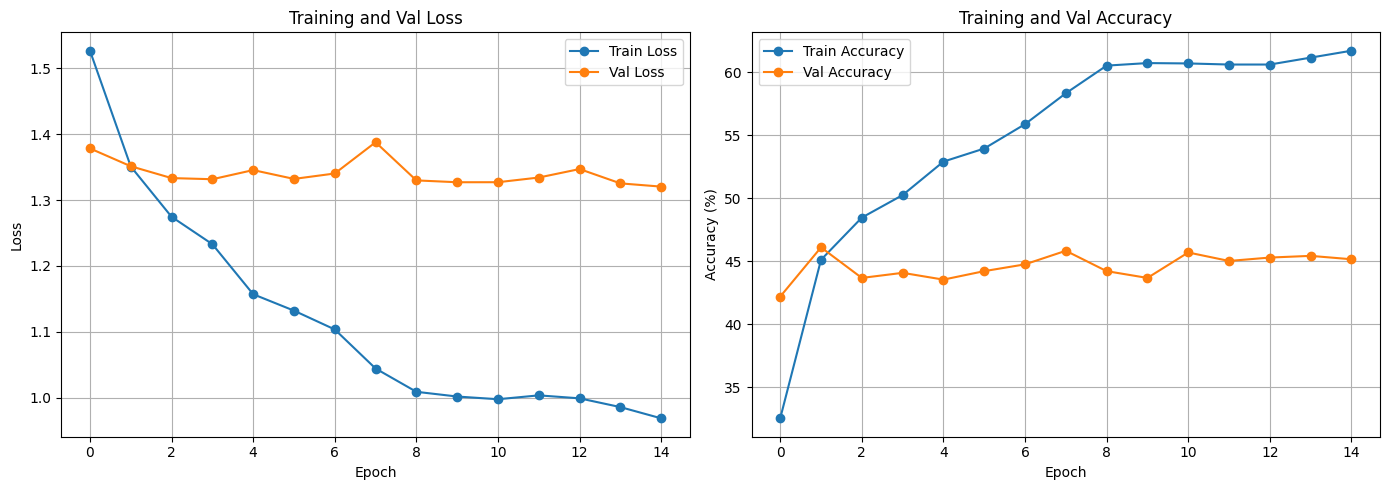

In [37]:
plot_accuracy(resnet2_train_losses, resnet2_train_accs, resnet2_val_losses, resnet2_val_accs)

#### Evaluating Test Set Performance

In [38]:
resnet2_test_loss, resnet2_test_acc, resnet2_actual, resnet2_pred = evaluate(resnet_model_2, test_loader, criterion, device, test=True)

print(f"ResNet-50 (2) Test Dataset Loss: {resnet2_test_loss:.2f}")
print('\n')
print(f"ResNet-50 (2) Test Dataset Accuracy {resnet2_test_acc:.2f}")

ResNet-50 (2) Test Dataset Loss: 1.31


ResNet-50 (2) Test Dataset Accuracy 45.09


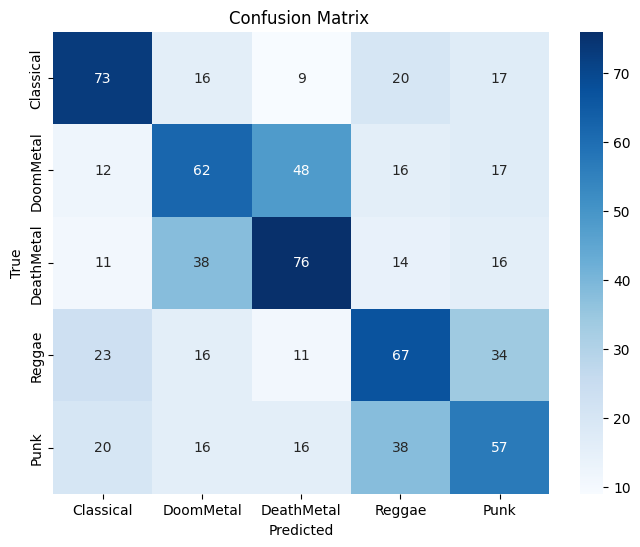

In [39]:
resnet2_cm = generate_confusion_matrix(resnet2_actual, resnet2_pred, SELECTED_GENRES)

## 6. Applying GRAD-CAM

### Helper Functions

In [40]:
def show_gradcam_example(cam, model, test_loader, device, class_names, idx=0):

  model.eval()  # set model to eval mode

  # get one batch
  images, labels = next(iter(test_loader))
  images = images.to(device)
  labels = labels.to(device)

  # get example
  input_tensor = images[idx:idx+1]  # shape: [1, 3, 224, 224]
  true_label = labels[idx].item()

  # forward pass to get predicted class
  with torch.no_grad():
    logits = model(input_tensor)
  pred_label = int(logits.argmax(dim=1).item())

  # unnormalize image
  mean = np.array([0.485, 0.456, 0.406])
  std  = np.array([0.229, 0.224, 0.225])
  img = input_tensor[0].detach().cpu().permute(1, 2, 0).numpy()
  img = (img * std + mean)
  img = np.clip(img, 0, 1)

  # run Grad-CAM for the predicted class -> see why the model predicted the class
  pred_targets = [ClassifierOutputTarget(pred_label)]
  pred_cam = cam(input_tensor=input_tensor, targets=pred_targets)[0]
  pred_overlay = show_cam_on_image(img, pred_cam, use_rgb=True)

  # run Grad-CAM for the true class -> what in the image provides signifiers to classify the true class
  true_targets = [ClassifierOutputTarget(true_label)]
  true_cam = cam(input_tensor=input_tensor, targets=true_targets)[0]
  true_overlay = show_cam_on_image(img, true_cam, use_rgb=True)

  # plot results
  plt.figure(figsize=(12,4))

  plt.subplot(1,4,1)
  plt.title("Original")
  plt.imshow(img)
  plt.axis("off")

  plt.subplot(1,4,2)
  plt.title("Pred CAM")
  plt.imshow(pred_overlay)
  plt.axis("off")

  plt.subplot(1,4,3)
  plt.title("True CAM")
  plt.imshow(true_overlay)
  plt.axis("off")

  plt.suptitle(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
  plt.tight_layout()
  plt.show()

### `resnet_model` 

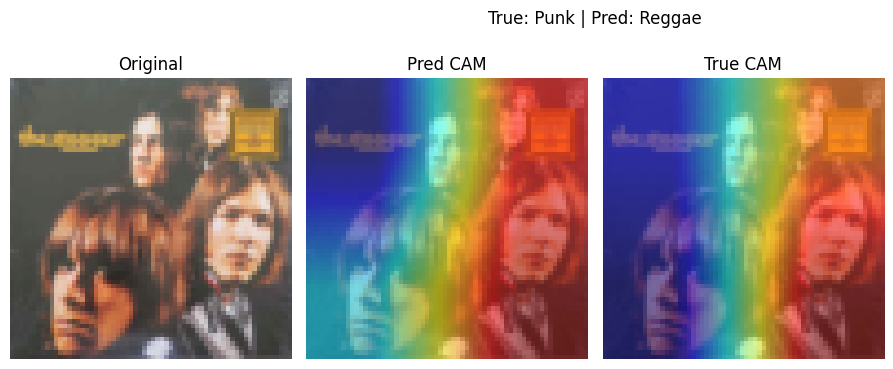

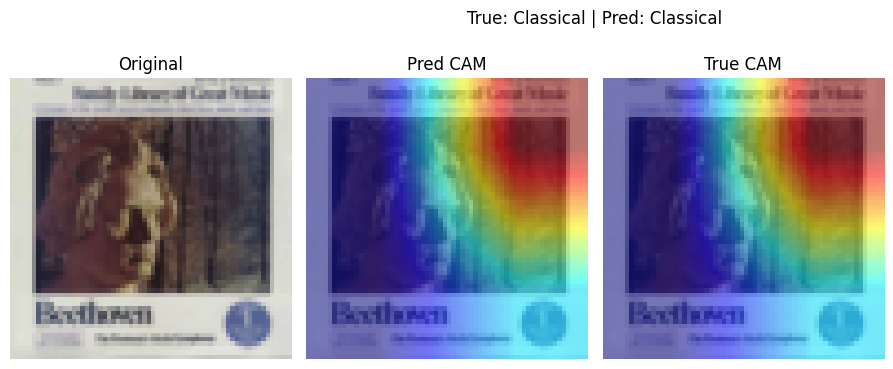

In [41]:
target_layers = [resnet_model.layer4[-1].conv3]

cam = GradCAM(model=resnet_model, target_layers=target_layers)
for i in range(2):
  show_gradcam_example(cam, baseline_model_gap, test_loader, device, SELECTED_GENRES, idx=i)

### `resnet_model_2`

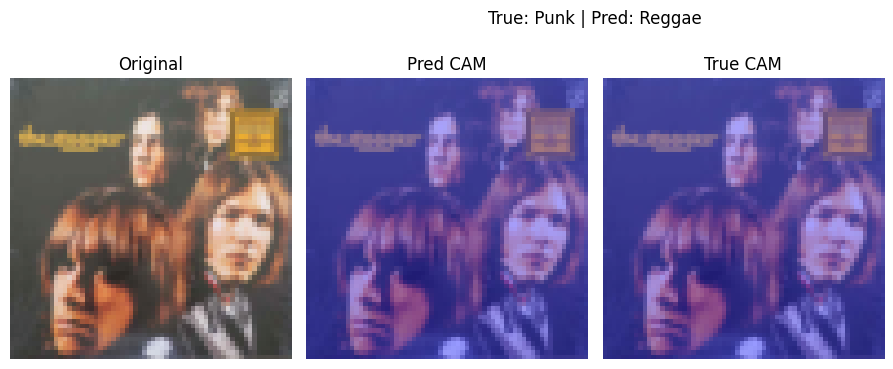

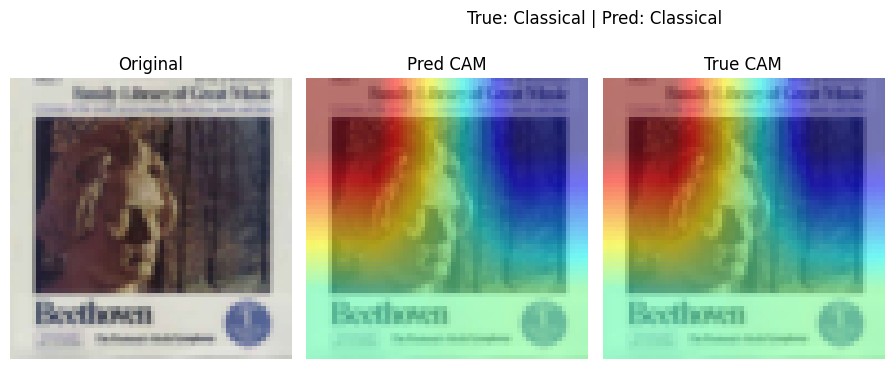

In [42]:
target_layers = [resnet_model_2.layer4[-1].conv3]

cam = GradCAM(model=resnet_model_2, target_layers=target_layers)
for i in range(2):
  show_gradcam_example(cam, baseline_model_gap, test_loader, device, SELECTED_GENRES, idx=i)

## 7. Additional Analysis 

## Comparing BaselineCNN (GAP) and ResNet (initial)

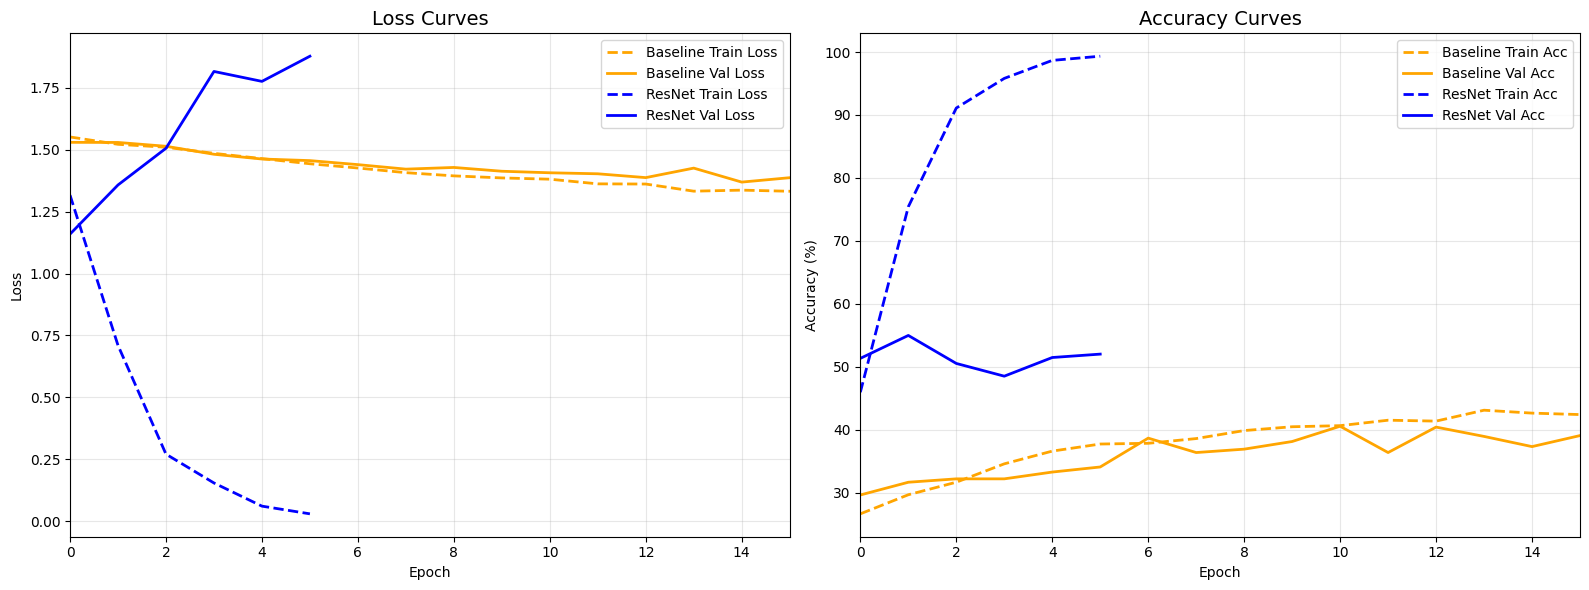

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: LOSS ---
# Baseline CNN 
axes[0].plot(baseline_gap_history['train_losses'], label='Baseline Train Loss', 
             color='orange', linestyle='--', linewidth=2)
axes[0].plot(baseline_gap_history['val_losses'], label='Baseline Val Loss', 
             color='orange', linestyle='-', linewidth=2)

# ResNet (Blue)
axes[0].plot(resnet_train_losses, label='ResNet Train Loss', 
             color='blue', linestyle='--', linewidth=2)
axes[0].plot(resnet_val_losses, label='ResNet Val Loss', 
             color='blue', linestyle='-', linewidth=2)

axes[0].set_title('Loss Curves', fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: ACCURACY  ---
# Baseline CNN 
axes[1].plot(baseline_gap_history['train_accs'], label='Baseline Train Acc', 
             color='orange', linestyle='--', linewidth=2)
axes[1].plot(baseline_gap_history['val_accs'], label='Baseline Val Acc', 
             color='orange', linestyle='-', linewidth=2)

# ResNet 
axes[1].plot(resnet_train_accs, label='ResNet Train Acc', 
             color='blue', linestyle='--', linewidth=2)
axes[1].plot(resnet_val_accs, label='ResNet Val Acc', 
             color='blue', linestyle='-', linewidth=2)

axes[1].set_title('Accuracy Curves', fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, 15)
    # Force x-axis to only show integers
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()